Generates data used in the am_summary display notebook.

In [ ]:
import sys
from pathlib import Path
HERE = Path.cwd().resolve()
up2_path = str((HERE / ".." / "..").resolve())
up3_path = str((HERE / ".." / ".." / "..").resolve())
for pathstr in [up2_path, up3_path]:
  if pathstr not in sys.path:
      sys.path.insert(0, pathstr)

from helpers import *
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generates
file1 = str((HERE / "data" / "histogram-4.pkl").resolve())
file2 = str((HERE / "data" / "histogram-5.pkl").resolve())
file3 = str((HERE / "data" / "histogram-6.pkl").resolve())

In [2]:
def solve_and_store(h, d, a, heaving, NMK, m0, rho, nmk_max, region = 0):
  prob = ConvergenceProblemI(h, d, a, heaving, NMK, m0, rho)
  mk = prob.m_k
  info = {"h" : h,
          "d" : d,
          "a" : a,
          "region" : region,
          "m0s" : [m0]}
  print(info)
  return merge_dicts(info, prob.convergence_study_over_m0s(nmk_max, [m0], [mk]))

In [3]:
# Generate file1 (histogram)
hmdrs = [20, 30]
right_ratios = [0.5, 0.95, 1.05, 1.3]
shielding_values = [-5, 5, 10, 15]

rho, big_nmk, nmk_max = 1023, 200, 150

def variable_values(cf):
  return {"(h-d0)/radwidth0" : (cf["h"]-cf["d"][0])/(cf["a"][0]),
          "(h-d1)/(h-d0)" : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]),
          "max((di-d0)/(a(i-1)-a0))" : max([(cf["d"][i] - cf["d"][0])/(cf["a"][i-1] - cf["a"][0]) for i in range(2, len(cf["d"]))])}

def generate_h_d_a_m0_3_region(hmdr, right_ratio, shielding_value):
  hmd0 = random.uniform(low = 0, high = 10)
  hmd1 = right_ratio * hmd0
  radwidth0 = hmd0/hmdr

  if shielding_value > 0:
    rad_max = hmd0/shielding_value
    radwidth1 = hmd1/random.uniform(low = max(1,hmd1 * 1.1/rad_max), high = 20)
  else:
    radwidth1 = hmd1/random.uniform(low = 1, high = 10)

  d_diff_max = shielding_value * radwidth1
  hmd2 = hmd0 - d_diff_max
  radwidth2 = hmd2/random.uniform(low = 1, high = 10)

  a = [radwidth0, radwidth0 + radwidth1, radwidth0 + radwidth1 + radwidth2]
  hmds = [hmd0, hmd1, hmd2]

  h_min = max(hmds)
  h = random.uniform(low = 1.1 * h_min, high = 3 * h_min)
  m0 = random.uniform(low = 1/h, high = 80/h)
  d = [h-hmd for hmd in hmds]
  for i in range(len(d)):
    assert d[i] > 0
    inner = 0 if i == 0 else a[i-1]
    assert a[i] > inner
  return h, d, a, m0

# all_prob_sets = []
# region_count, heaving, NMK = 3, [1, 0, 0], [big_nmk] * 4
# for hmdr in hmdrs:
#   for right_ratio in right_ratios:
#     for shielding_value in shielding_values:
#       prob_set = []
#       for i in range(50):
#         h, d, a, m0 = generate_h_d_a_m0_3_region(hmdr, right_ratio, shielding_value)
#         prob_set.append(solve_and_store(h, d, a, heaving, NMK, m0, rho, nmk_max))
#       all_prob_sets.append(prob_set)
#       update_data_file(all_prob_sets, file1)
#       print("Finished a set.", region_count, hmdr, right_ratio, shielding_value)

hist_prob_sets = open_pkl_file(file1)
for subset in hist_prob_sets:
  generate_convergence_data(subset, [0.01, 0.005])
  generate_log_data(subset)

In [4]:
# Generate file2, repeated runs for right ratio > 1, now with fixed r0/r1.
hmdrs = [20, 30]
right_ratios = [1.05, 1.3]
shielding_values = [-5, 5, 10, 15]
rho, big_nmk, nmk_max = 1023, 200, 150

def generate_h_d_a_m0_3_region_v2(hmdr, right_ratio, shielding_value):
  hmd0 = random.uniform(low = 0, high = 10)
  hmd1 = right_ratio * hmd0
  radwidth0 = hmd0/hmdr
  rad_min = radwidth0 * right_ratio * hmdr / 20

  if shielding_value > 0:
    rad_max = hmd0/shielding_value
  else:
    rad_max = radwidth0 * right_ratio * hmdr
  radwidth1 = (rad_max + rad_min)/2

  d_diff_max = shielding_value * radwidth1
  hmd2 = hmd0 - d_diff_max
  radwidth2 = hmd2/random.uniform(low = 1, high = 10)

  a = [radwidth0, radwidth0 + radwidth1, radwidth0 + radwidth1 + radwidth2]
  hmds = [hmd0, hmd1, hmd2]

  h_min = max(hmds)
  h = random.uniform(low = 1.1 * h_min, high = 3 * h_min)
  m0 = random.uniform(low = 1/h, high = 80/h)
  d = [h-hmd for hmd in hmds]
  for i in range(len(d)):
    assert d[i] > 0
    inner = 0 if i == 0 else a[i-1]
    assert a[i] > inner
  return h, d, a, m0

def variable_values(cf):
  return {"(h-d0)/radwidth0" : (cf["h"]-cf["d"][0])/(cf["a"][0]),
          "(h-d1)/(h-d0)" : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]),
          "max((di-d0)/(a(i-1)-a0))" : max([(cf["d"][i] - cf["d"][0])/(cf["a"][i-1] - cf["a"][0]) for i in range(2, len(cf["d"]))]),
          "radwidth0/a1" : cf["a"][0]/cf["a"][1]}

# all_prob_sets = []
# region_count, heaving, NMK = 3, [1, 0, 0], [big_nmk] * 4
# for hmdr in hmdrs:
#   for right_ratio in right_ratios:
#     for shielding_value in shielding_values:
#       prob_set = []
#       for i in range(50):
#         h, d, a, m0 = generate_h_d_a_m0_3_region_v2(hmdr, right_ratio, shielding_value)
#         prob_set.append(solve_and_store(h, d, a, heaving, NMK, m0, rho, nmk_max))
#       all_prob_sets.append(prob_set)
#       update_data_file(all_prob_sets, file2)
#       print("Finished a set.", region_count, hmdr, right_ratio, shielding_value)

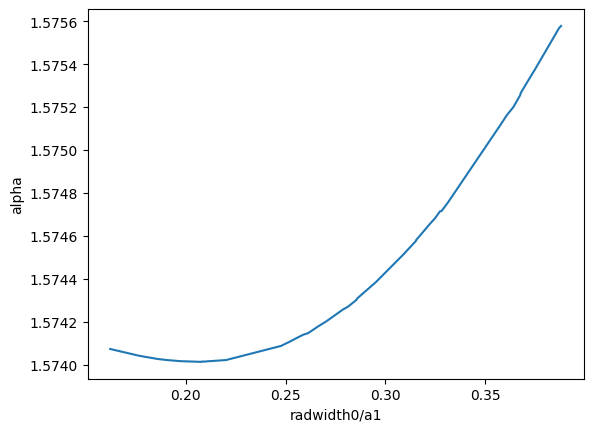

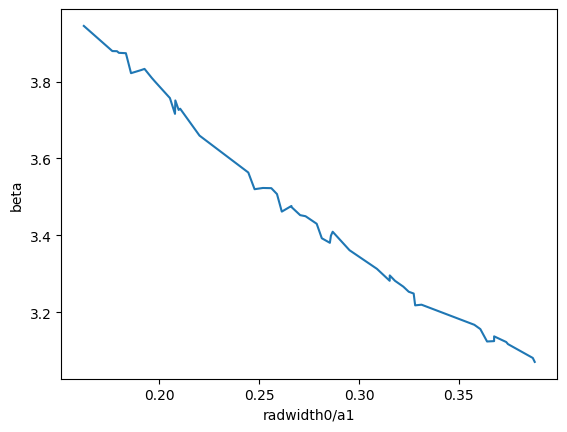

In [9]:
def f(x, a1, a2):
  return - a1 * np.log(x/a2)

variable_funcs = {"radwidth0/a1" : lambda cf, m0 : cf["a"][0]/cf["a"][1]}
key = "radwidth0/a1"

data = hist_prob_sets[25]
data = sorted(data, key=lambda cf: variable_funcs[key](cf, cf["m0s"][0]))
meta_xs, meta_ys1, meta_ys2 = [], [], []
for cf in data:
    xs = list(range(1, 151))
    ys = [cf[cf["m0s"][0]]["log errors am"][i] for i in range(150)]
    # xs, ys = loc_max(xs, ys)
    popt, pcov = curve_fit(f, xs, ys, p0=(1, 1))
    # print("Best-fit parameters:", popt)
    meta_xs.append(variable_funcs[key](cf, cf["m0s"][0]))
    meta_ys1.append(popt[0])
    meta_ys2.append(popt[1])
    # ys_calc = [f(x, *popt) for x in list(range(1, 151))]
    # plt.plot(xs, ys, label="Data")
    # plt.plot(list(range(1, 151)), ys_calc, color="red", label="Fit")
    # plt.legend()
    # plt.show()

plt.plot(meta_xs, meta_ys1)
# popt, pcov = curve_fit(meta_f1, meta_xs, meta_ys1, p0=(1, 2, 3))
# print("Best-fit parameters:", popt)
# plt.plot(meta_xs, [meta_f1(x, *popt) for x in meta_xs])
plt.xlabel(key)
plt.ylabel("alpha")
plt.show()

plt.plot(meta_xs, meta_ys2)
# popt, pcov = curve_fit(meta_f2, meta_xs, meta_ys2, p0=(1, 2, 3))
# print("Best-fit parameters:", popt)
# plt.plot(meta_xs, [meta_f1(x, *popt) for x in meta_xs])
plt.xlabel(key)
plt.ylabel("beta")
plt.show()

In [ ]:
# Data to confirm shielding independence (just (h-d0)/radwidth0, (h-d1)/(h-d0)) if (h-d2)>(h-d1)
hmdrs = [30]
right_ratios = [0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.01, 1.05, 1.1, 1.3, 1.5, 2, 2.5, 3]

rho, big_nmk, nmk_max = 1023, 200, 150

def generate_h_d_a_m0_3_region_no_shield(hmdr, right_ratio):
  hmd0 = random.uniform(low = 0, high = 10)
  hmd1 = right_ratio * hmd0
  hmd2 = random.uniform(low = 1.01, high = 5) * hmd1
  radwidth0 = hmd0/hmdr
  radwidth1 = hmd1/random.uniform(low = 1, high = 10)
  radwidth2 = hmd2/random.uniform(low = 1, high = 10)

  hmds = [hmd0, hmd1, hmd2]
  radwidths = [radwidth0, radwidth1, radwidth2]

  h = random.uniform(low = 1.01, high = 3) * max(hmds)
  m0 = random.uniform(low = 1, high = 60)/h
  a = [sum(radwidths[0:i+1]) for i in range(3)]
  d = [h - hmd for hmd in hmds]
  return h, d, a, m0

def generate_h_d_a_m0_multi_region_no_shield(hmdr, right_ratio, regions):
  hmd0 = random.uniform(low = 0, high = 10)
  hmd1 = right_ratio * hmd0
  hmds = [hmd0, hmd1]

  for i in range(2, regions):
    hmds.append(random.uniform(low = 1.01, high = 3) * hmds[-1])

  radwidths = [hmd0/hmdr]
  for i in range(1, regions):
    radwidths.append(hmds[i]/random.uniform(low = 1, high = 10))

  h = random.uniform(low = 1.01, high = 3) * max(hmds)
  m0 = random.uniform(low = 1, high = 60)/h
  a = [sum(radwidths[0:i+1]) for i in range(regions)]
  d = [h - hmd for hmd in hmds]
  return h, d, a, m0

# all_prob_sets = [[], []]
# region_count, heaving, NMK = 3, [1, 0, 0], [big_nmk] * 4
# for hmdr in hmdrs:
#   for right_ratio in right_ratios:
#     prob_set = []
#     for i in range(30):
#       h, d, a, m0 = generate_h_d_a_m0_3_region_no_shield(hmdr, right_ratio)
#       prob_set.append(solve_and_store(h, d, a, heaving, NMK, m0, rho, nmk_max))
#     all_prob_sets[0].append(prob_set)
#     update_data_file(all_prob_sets, file3)
#     print("Finished a set.", region_count, hmdr, right_ratio)

# region_counts = [4, 5, 6]
# right_ratios = [0.5, 0.95, 1.05, 1.1, 1.3, 2]
# for hmdr in hmdrs:
#   for right_ratio in right_ratios:
#     for region_count in region_counts:
#       heaving, NMK = [region == 0 for region in range(region_count)], [big_nmk] * (region_count + 1)
#       prob_set = []
#       for i in range(30):
#         h, d, a, m0 = generate_h_d_a_m0_multi_region_no_shield(hmdr, right_ratio, region_count)
#         prob_set.append(solve_and_store(h, d, a, heaving, NMK, m0, rho, nmk_max))
#       all_prob_sets[1].append(prob_set)
#       update_data_file(all_prob_sets, file3)
#       print("Finished a set.", region_count, hmdr, right_ratio)

{'h': 16.826890308619166, 'd': [10.317233768143634, 14.873993346476507, 8.72479226161942], 'a': [0.2169885513491844, 0.49393576507149906, 2.465248442660689], 'region': 0, 'm0s': [0.8025604721387013]}
{'h': 5.625275020777137, 'd': [1.6474175877443278, 4.431917790867294, 1.7043308505077839], 'a': [0.1325952477677603, 0.4138975115167438, 4.027734243765274], 'region': 0, 'm0s': [10.070459823648912]}
{'h': 27.537082430727736, 'd': [20.80704427035265, 25.51807098261521, 18.00320174014285], 'a': [0.2243346053458361, 0.5867935180750509, 3.1029829182877684], 'region': 0, 'm0s': [1.9752462337056254]}
{'h': 9.520197639437706, 'd': [5.954036615811227, 8.450349332349763, 7.147318261992684], 'a': [0.11887203412088262, 0.49601889689349477, 0.7444733949039082], 'region': 0, 'm0s': [1.9585968481954137]}
{'h': 10.043826306727398, 'd': [6.627545033134519, 9.018941924649534, 7.456364402941476], 'a': [0.11387604245309599, 0.22962997892494186, 0.9112102440880517], 'region': 0, 'm0s': [3.1818143505015373]}
{